# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *

import model as m       # I've put all the functions in a separate Python file


(ipykernel_launcher.py:137443): dbind-WARNING **: 17:31:34.859: AT-SPI: Error retrieving accessibility bus address: org.freedesktop.DBus.Error.ServiceUnknown: The name org.a11y.Bus was not provided by any .service files


In [2]:
# parameters of the simulation
par={'N': 2,                    # side length of the squared lattice
     'int_range': 1,             # interaction range
     'p_self_link': 0,         # probability for each cell of having a self link
     'J_range': [-1,+1],                       # define the possible value for J.
     'J_mutation_radius': 0.1,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.1,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 0.1,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.8,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'length_powerlaw': 1,         # exponent of the wire length power law (DA DEFINIRE!!!)
     'x_n': np.linspace(-1,1,20),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'T_initial': lambda x: 0 + 1*x,              # initial transfer function shape (here linear)
     'target_set': [0.0,1.0,1.0,0.0],
     'input_set':[[0,0],[0,1],[1,0],[1,1]],
     'n_iter': 10,
     'N_sol': 10}                       # number of solutions (individuals, networks) considered in the simulation

#nrd.seed(1234)

In [3]:
n_parents = int(np.floor(par['N_sol'] * par['reproduction_ratio'])-np.floor(par['N_sol'] * par['reproduction_ratio'])%2)
n_parents

8

In [4]:
sol, fmean = m.evolution(par,verb=3,gen_verb=False)

/home/pietromalagoli/ne/main/model.py:110: ComplexWarning: Casting complex values to real discards the imaginary part
  state[cell] = new_fun(contributions[cell])    # apply the new functional as the T function for the associated cell
/home/pietromalagoli/ne/main/model.py:154: ComplexWarning: Casting complex values to real discards the imaginary part
  T1[cell,:] = np.append(par1.T[cell,:cut_idx[cell]],par2.T[cell,cut_idx[cell]:])
/home/pietromalagoli/ne/main/model.py:155: ComplexWarning: Casting complex values to real discards the imaginary part
  T2[cell,:] = np.append(par2.T[cell,:cut_idx[cell]],par1.T[cell,cut_idx[cell]:])


fitness: [26.398846164339353, 28.515659313460603, 31.176494884144105, 32.47346607004637, 65.87122419124861, 104.13548768652439, 2780.2969656732357, 19862.423641493788, 1072332.5726350385, 1851849053870263.2]
Fitness_inv:[3.78804435e-02 3.50684510e-02 3.20754467e-02 3.07943722e-02
 1.51811358e-02 9.60287432e-03 3.59673809e-04 5.03463232e-05
 9.32546512e-07 5.40000816e-16]
Prob:[2.35262273e-01 2.17797965e-01 1.99209455e-01 1.91253146e-01
 9.42847600e-02 5.96401160e-02 2.23380906e-03 3.12683521e-04
 5.79172238e-06 3.35375745e-15]
Iteration #0...
Mean fitness: 185184905496552.7
fitness: [30.58753419525764, 35.23454635831993, 35.86059667913997, 38.20339531945268, 50.316063096103036, 55.11456832410514, 111.06829653393933, 137.145660562111, 138.48656924961898, 181.2339862243608]
Fitness_inv:[0.03269306 0.02838124 0.02788576 0.02617568 0.01987437 0.01814402
 0.00900347 0.00729152 0.00722092 0.00551773]
Prob:[0.17944705 0.15578015 0.15306056 0.14367422 0.10908729 0.09958969
 0.04941863 0.040021

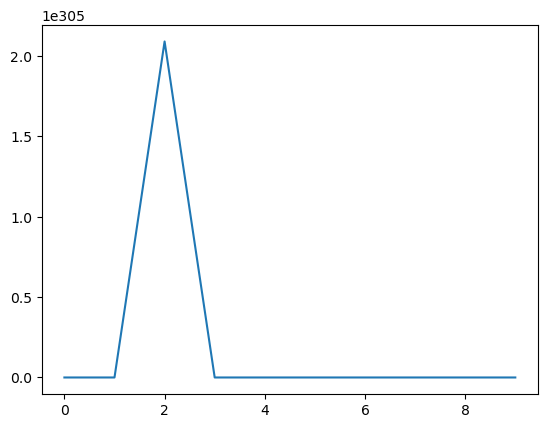

In [5]:
plt.plot(fmean)

In [6]:
n1 = m.generate(par)
n2 = m.generate(par)

o1, o2 = m.crossover(n1,n2)